# 01 — What is actually in this dataset?

**Goal of this notebook:** before we decode anything, establish exactly what the file
contains, and *verify* rather than assume every property the analysis will depend on.

By the end you will know: how many trials, channels and time bins there are; what one
"sample" of neural data physically means; where `t = 0` sits; how the eight movement
directions are derived; and where the go cue falls relative to our analysis window.

---

## The recording

The data come from **intracortical microelectrode arrays** ("Utah arrays") implanted in
the motor cortex of people enrolled in the BrainGate2 clinical trial. Each array is a
grid of ~100 silicon shanks, roughly 1.5 mm long, whose tips sit among cortical neurons.
Each electrode picks up the extracellular voltage nearby.

Two features are extracted from each electrode, and both are in this file:

- **Threshold crossings** (`spike_data_all`) — the raw signal is band-pass filtered to
  250–5000 Hz, and every time the voltage crosses a threshold, that is counted as a
  spike-like event. This is *not* spike sorting: no attempt is made to decide which
  neuron produced which event, so one channel reports the pooled activity of the few
  neurons near that electrode ("multi-unit activity"). It is coarser than sorted single
  units, but it is stable and it is what real-time BCIs actually use.
- **Spike-band power** (`sbp_data_all`) — the power in that same frequency band, which
  captures spiking activity that never quite crosses the threshold.

We use **threshold crossings only** in this prototype. One feature per channel, and each
one is interpretable as a firing rate, which makes every later step easier to reason about.

## The task

An **instructed-delay** (or "memory-guided", "delayed-reach") task. On each trial:

```
target appears  ------ delay (1.0 or 1.5 s) ------  go cue  ------ attempted movement
     t = 0                                          t = delay
```

The participant is shown *where* to move, then has to **wait**. That enforced gap is the
entire point of the design: it separates *knowing what movement to make* from *making
it*. Any directional information present during the delay cannot be a consequence of the
movement, because the movement has not happened yet. This is what lets us ask our
scientific question at all.

The participant here attempts wrist movements to one of **eight radial targets**; the
attempt drives a cursor on screen. Some trials are **no-go / catch trials** where the go
cue never arrives — we set those aside for now (see notebook 03).

In [ ]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd

# Make the project root importable (config.py and src/ live one level up).
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import config
from src import data_loading, plotting
from src.data_loading import load_trial_data, describe_h5, resolve_data_file

np.random.seed(config.RANDOM_STATE)
plotting.use_house_style()
config.ensure_output_dirs()

print(f"participant : {config.PARTICIPANT}")
print(f"alignment   : {config.ALIGNMENT}  (t = 0 is the start of this epoch)")
print(f"feature     : {config.FEATURE_TYPE}")

participant : T16
alignment   : delay  (t = 0 is the start of this epoch)
feature     : spikes


## 1. Every key in the file

Never trust a variable list from documentation alone — print what the file actually
holds. The Dryad README promises certain fields; this is where we check.

In [2]:
path = resolve_data_file(config.PARTICIPANT, config.ALIGNMENT, config.FIGURE,
                         config.candidate_data_dirs())
print(f"file: {path}")
print(f"size: {path.stat().st_size / 1e6:.1f} MB\n")

keys_df = pd.DataFrame(describe_h5(path))
keys_df

file: C:\Users\gilad\Intracortical_project\fig1_T16_delay.h5
size: 58.2 MB



,key,shape,dtype
0,block_id_data_all,"(385,)",float64
1,cursor_data_all,"(385, 150, 2)",float64
2,delay_data_all,"(385,)",float64
3,emg_data_all,"(385, 150, 2)",float64
4,keep_chans_all,"(61,)",int64
5,no_go_bool_all,"(385,)",float64
6,sbp_data_all,"(385, 150, 61)",float64
7,spike_data_all,"(385, 150, 61)",float64
8,start_data_all,"(385, 2)",float64
9,t_data,"(150,)",int64


Reading the shapes above against the dataset README:

| field | shape | meaning |
|---|---|---|
| `spike_data_all` | (trials, bins, channels) | smoothed threshold-crossing counts per bin |
| `sbp_data_all` | (trials, bins, channels) | smoothed spike-band power |
| `target_data_all` / `start_data_all` | (trials, 2) | target and start position, `[X, Y]` in pixels |
| `delay_data_all` | (trials,) | instructed delay duration, in seconds |
| `no_go_bool_all` | (trials,) | 0 = go trial, 1 = no-go catch trial |
| `block_id_data_all` | (trials,) | which recording block the trial came from |
| `keep_chans_all` | (channels,) | which electrodes survived the >2 Hz firing-rate cut |
| `cursor_data_all` | (trials, bins, 2) | cursor position through the trial |
| `t_data` | (bins,) | time of each bin relative to the alignment event, in ms |

`block_id_data_all` looks like bookkeeping but is scientifically important — it becomes
the grouping variable for cross-validation in notebook 03.

## 2. Load it, and check the shapes agree with each other

`load_trial_data` raises rather than returning something half-valid: it checks that the
required fields exist, that the per-trial arrays all report the same number of trials,
that the channel counts match, and — importantly — that `t_data` is *uniformly* spaced
instead of assuming a 20 ms bin.

In [3]:
td = load_trial_data(config.PARTICIPANT, config.ALIGNMENT, config.FIGURE,
                     config.candidate_data_dirs())
td

TrialData(T16/delay: 385 trials x 150 bins x 61 chans, bin=20 ms, t=-1000..1980 ms)

In [4]:
print(f"trials            : {td.n_trials}")
print(f"channels          : {td.n_channels}   (electrodes kept, of ~192 implanted)")
print(f"time bins         : {td.n_bins}")
print(f"bin width         : {td.bin_s * 1000:.0f} ms")
print(f"t_data range      : {td.t_ms[0]:.0f} to {td.t_ms[-1]:.0f} ms "
      f"(relative to {config.ALIGNMENT} onset)")
print(f"epoch duration    : {(td.t_ms[-1] - td.t_ms[0]) / 1000:.2f} s")
print(f"blocks            : {np.unique(td.block).astype(int).tolist()}")
print(f"electrode indices : {td.keep_chans[:8].tolist()} ... {td.keep_chans[-3:].tolist()}")

trials            : 385
channels          : 61   (electrodes kept, of ~192 implanted)
time bins         : 150
bin width         : 20 ms
t_data range      : -1000 to 1980 ms (relative to delay onset)
epoch duration    : 2.98 s
blocks            : [12, 13, 14, 15, 16, 17]
electrode indices : [137, 145, 146, 152, 154, 160, 162, 168] ... [251, 252, 253]


## 3. What one number in `spike_data_all` means

This is the single most important unit question in the notebook, and it is worth being
slow about.

The value is a **threshold-crossing count per bin**, after smoothing. So a value of
`0.16` in a 20 ms bin corresponds to `0.16 / 0.020 = 8` crossings per second, i.e. **8 Hz**.
We convert to Hz for anything we look at by eye, because "8 Hz" is a quantity a
physiologist can sanity-check and "0.16 counts/bin" is not.

Note the values are not integers. That is because of the smoothing described next.

In [5]:
spikes = td.spikes
rate_hz = spikes / td.bin_s     # counts per bin -> Hz

print(f"raw values : min {spikes.min():.4f}  max {spikes.max():.4f}  "
      f"mean {spikes.mean():.4f} counts/bin")
print(f"as rates   : min {rate_hz.min():.2f}  max {rate_hz.max():.2f}  "
      f"mean {rate_hz.mean():.2f} Hz")
print(f"integers?  : {np.allclose(spikes, np.round(spikes))}   "
      f"(False => the counts have been smoothed)\n")

per_channel_hz = rate_hz.mean(axis=(0, 1))
print("mean firing rate per channel (Hz):")
print(f"  min {per_channel_hz.min():.1f} | median {np.median(per_channel_hz):.1f} "
      f"| max {per_channel_hz.max():.1f}")
print(f"  channels below 2 Hz: {(per_channel_hz < 2).sum()}  "
      f"(expected 0 — the dataset already applied this cut)")

raw values : min 0.0000  max 2.3122  mean 0.1632 counts/bin
as rates   : min 0.00  max 115.61  mean 8.16 Hz
integers?  : False   (False => the counts have been smoothed)

mean firing rate per channel (Hz):
  min 2.4 | median 8.1 | max 27.3
  channels below 2 Hz: 0  (expected 0 — the dataset already applied this cut)


> ### ⚠️ The preprocessing caveat that governs this whole project
>
> These features arrive **already smoothed, acausally, with a Gaussian kernel of
> σ = 100 ms**. "Acausal" means the kernel is centred: the value at time *t* is a
> weighted average of activity *both before and after* *t*.
>
> Three consequences we carry through every later notebook:
>
> 1. **Do not smooth again.** Any additional large kernel would compound something that
>    has already been applied.
> 2. **Never claim a precise onset latency.** If decoding accuracy starts climbing at
>    t = 80 ms, that does not mean the cortex responded at 80 ms — activity from
>    t = 180 ms has already leaked backwards into that bin.
> 3. **Neighbouring time bins are not independent.** Bins 20 ms apart share most of
>    their smoothing window, so the time-resolved curve in notebook 03 is much smoother
>    than the underlying data, and adjacent points are heavily correlated.
>
> Our claims will therefore be about the **presence and temporal structure** of
> preparatory information — not about when exactly it appeared.

## 4. Deriving the eight movement directions

The file does not store "direction" as a label. It stores where the cursor started and
where the target was, both in screen pixels. Direction is the angle of the vector
between them:

$$\theta = \operatorname{atan2}(y_{target} - y_{start},\; x_{target} - x_{start})$$

mapped into $[0, 2\pi)$. We then assign each trial to one of 8 classes 45° apart.

The important part is the **check**, not the arithmetic. We could round any set of angles
into 8 bins and get labels that look fine. So we measure how far each trial sits from the
grid angle it was assigned to, and refuse to continue if any trial is off by more than a
few degrees. If this is not a clean radial-8 task, we want an error, not plausible labels.

In [6]:
delta = td.target - td.start
theta = np.mod(np.arctan2(delta[:, 1], delta[:, 0]), 2 * np.pi)

spacing = 2 * np.pi / config.N_DIRECTIONS
labels = np.rint(theta / spacing).astype(int) % config.N_DIRECTIONS

# How far is each trial from its assigned ideal grid angle?
ideal = labels * spacing
residual_deg = np.degrees(np.abs(np.angle(np.exp(1j * (theta - ideal)))))

print(f"distinct start positions : {np.unique(td.start, axis=0).tolist()}")
print(f"movement amplitudes (px) : {np.unique(np.round(np.hypot(*delta.T), 2)).tolist()}")
print(f"worst deviation from an ideal 45° grid angle : {residual_deg.max():.4f}°")

if residual_deg.max() > 5.0:
    raise ValueError("Directions do not form a clean radial-8 grid.")
print("--> the targets really do lie on 8 evenly spaced radial directions")

distinct start positions : [[0.0, 0.0]]
movement amplitudes (px) : [400.0]
worst deviation from an ideal 45° grid angle : 0.0000°
--> the targets really do lie on 8 evenly spaced radial directions


In [7]:
# The same derivation, validated, is available as a reusable function from here on.
from src.preprocessing import direction_labels

labels, centres = direction_labels(td.target, td.start, config.N_DIRECTIONS)
assert np.array_equal(labels, np.rint(theta / spacing).astype(int) % config.N_DIRECTIONS)

counts = np.bincount(labels, minlength=config.N_DIRECTIONS)
pd.DataFrame({
    "direction": range(config.N_DIRECTIONS),
    "angle_deg": np.degrees(centres).astype(int),
    "compass": plotting.DIRECTION_ARROWS,
    "n_trials": counts,
})

,direction,angle_deg,compass,n_trials
0,0,0,→,48
1,1,45,↗,47
2,2,90,↑,48
3,3,135,↖,49
4,4,180,←,48
5,5,225,↙,48
6,6,270,↓,49
7,7,315,↘,48


## 5. Trial structure: delays, go/no-go, and blocks

Three things we need to know before designing the decoding analysis:

- **How long are the delays?** This determines how much purely preparatory time we have.
- **How many no-go trials?** These are catch trials with no go cue at all.
- **How are trials distributed across recording blocks?** Blocks are separate recording
  runs, minutes apart. Neural signals drift between them, which is exactly why they will
  become our cross-validation groups.

In [8]:
finite_delay = np.isfinite(td.delay)
print("Instructed delay durations")
vals, cnts = np.unique(np.round(td.delay[finite_delay], 3), return_counts=True)
for v, c in zip(vals, cnts):
    print(f"  {v:.2f} s : {c} trials")
if (~finite_delay).any():
    print(f"  NaN     : {(~finite_delay).sum()} trials")
print(f"  range   : {np.nanmin(td.delay):.2f} – {np.nanmax(td.delay):.2f} s\n")

n_go = int((td.no_go == 0).sum())
n_nogo = int((td.no_go == 1).sum())
n_unknown = int(td.n_trials - n_go - n_nogo)
print(f"Go trials    : {n_go}")
print(f"No-go trials : {n_nogo}")
if n_unknown:
    print(f"Unlabelled   : {n_unknown}  (non-finite no_go flag)")

Instructed delay durations
  1.00 s : 190 trials
  1.50 s : 195 trials
  range   : 1.00 – 1.50 s

Go trials    : 264
No-go trials : 121


In [9]:
print(f"Recording blocks: {np.unique(td.block).astype(int).tolist()}\n")

crosstab = pd.crosstab(
    pd.Series(td.block.astype(int), name="block"),
    pd.Series(labels, name="direction"),
)
crosstab["total"] = crosstab.sum(axis=1)
print("trials per block x direction (all trials):")
crosstab

Recording blocks: [12, 13, 14, 15, 16, 17]

trials per block x direction (all trials):


direction,0,1,2,3,4,5,6,7,total
block,,,,,,,,,
12,8,8,8,8,8,8,8,7,63
13,8,8,8,8,8,8,9,8,65
14,8,7,7,8,8,8,8,8,62
15,8,8,9,8,8,8,8,9,66
16,8,8,8,9,8,8,8,8,65
17,8,8,8,8,8,8,8,8,64


Read the row totals and the spread across columns. What matters for notebook 03 is
whether **every block contains every direction** — if some block were missing a direction
entirely, holding that block out would leave a fold with a class the decoder never has to
predict, and grouped cross-validation would break down.

## 6. Missing data

Check for NaNs before they silently propagate into a mean or a model fit.

In [10]:
def nan_report(name, arr):
    n_bad = int(np.isnan(arr).sum())
    if arr.ndim == 3:
        bad_trials = int(np.isnan(arr).any(axis=(1, 2)).sum())
    elif arr.ndim == 2:
        bad_trials = int(np.isnan(arr).any(axis=1).sum())
    else:
        bad_trials = int(np.isnan(arr).sum())
    print(f"  {name:24s}: {n_bad:7d} NaN values across {bad_trials} trial(s)")

print("NaN audit")
nan_report("spike_data_all", td.spikes)
nan_report("sbp_data_all", td.sbp)
nan_report("target_data_all", td.target)
nan_report("delay_data_all", td.delay)
nan_report("no_go_bool_all", td.no_go)
if td.cursor is not None:
    nan_report("cursor_data_all", td.cursor)

NaN audit
  spike_data_all          :       0 NaN values across 0 trial(s)
  sbp_data_all            :       0 NaN values across 0 trial(s)
  target_data_all         :       0 NaN values across 0 trial(s)
  delay_data_all          :       0 NaN values across 0 trial(s)
  no_go_bool_all          :       0 NaN values across 0 trial(s)
  cursor_data_all         :       0 NaN values across 0 trial(s)


## 7. Where is the go cue? (verifying the alignment ourselves)

The README says `t = 0` is the start of the delay period, i.e. when the target appears,
and that the go cue follows after the instructed delay. Rather than take that on trust,
we can **recover the event timing from the data itself**: the cursor cannot move until the
participant attempts a movement, and they should not attempt one until the go cue.

So we compute cursor speed over time, separately for each delay condition. If the
alignment is what we think it is, motion should begin just after `t = delay` — and no-go
trials should never move at all.

In [11]:
cursor = td.cursor
speed = np.linalg.norm(np.diff(cursor, axis=1), axis=2) / td.bin_s   # px/s
t_speed = td.t_ms[1:]

go_mask = td.no_go == 0
delay_values = np.unique(td.delay[np.isfinite(td.delay) & go_mask])

print("Cursor motion onset, by delay condition (go trials):")
go_cue_times_ms = []
for d in delay_values:
    m = go_mask & (td.delay == d)
    prof = np.nanmean(speed[m], axis=0)
    onset = t_speed[prof > 0.05 * np.nanmax(prof)]
    print(f"  delay {d:.1f} s  (n={m.sum():3d}) : motion begins ~{onset[0]:.0f} ms, "
          f"peak speed at {t_speed[np.nanargmax(prof)]:.0f} ms")
    go_cue_times_ms.append(d * 1000)

if (td.no_go == 1).any():
    prof_nogo = np.nanmean(speed[td.no_go == 1], axis=0)
    print(f"\n  no-go trials       : peak cursor speed = {np.nanmax(prof_nogo):.3f} px/s "
          f"(should be ~0 — the cursor never moves)")

Cursor motion onset, by delay condition (go trials):
  delay 1.0 s  (n=122) : motion begins ~1040 ms, peak speed at 1580 ms
  delay 1.5 s  (n=142) : motion begins ~1540 ms, peak speed at 1980 ms

  no-go trials       : peak cursor speed = 0.000 px/s (should be ~0 — the cursor never moves)


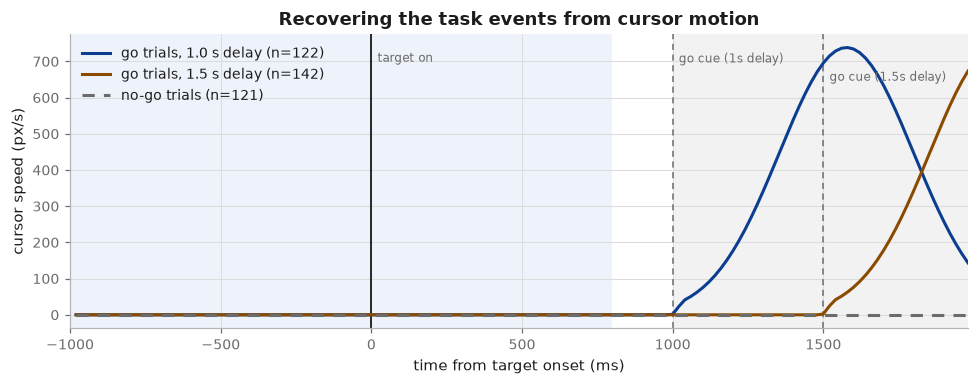

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.set_xlim(td.t_ms[0], td.t_ms[-1])
plotting.annotate_events(ax, go_cue_times_ms, config.PREP_WINDOW_MS)

for d, color in zip(delay_values, ["#0b3d91", "#8a4b00"]):
    m = go_mask & (td.delay == d)
    ax.plot(t_speed, np.nanmean(speed[m], axis=0), color=color,
            label=f"go trials, {d:.1f} s delay (n={m.sum()})")
if (td.no_go == 1).any():
    ax.plot(t_speed, np.nanmean(speed[td.no_go == 1], axis=0), color="#6b6b6b",
            ls=(0, (4, 3)), label=f"no-go trials (n={int((td.no_go == 1).sum())})")

ax.set_xlabel("time from target onset (ms)")
ax.set_ylabel("cursor speed (px/s)")
ax.set_title("Recovering the task events from cursor motion")
ax.legend(loc="upper left")
fig.tight_layout()
plt.show()

**This plot defines our analysis window.** The blue shaded band is the region where a
*preparatory* claim is defensible; the grey band is where preparation and execution mix.

Two features of the design matter:

- Motion begins right after each condition's go cue, confirming `t = 0` is target onset.
- The delays differ across trials (1.0 s and 1.5 s here), so **the go cue does not fall
  at a single time**. After the earliest go cue, the trial set is a mixture: some trials
  are still preparing while others are already moving.

Combined with the acausal 100 ms smoothing, we therefore treat
**t ∈ [−1000, +800] ms** as the strictly preparatory window — stopping 200 ms short of
the earliest go cue, because bins closer than that already contain post-go activity
smeared backwards. We will still decode across the whole epoch (it is informative to see
execution), but only the shaded blue region supports the claim "this is preparation".

## 8. Dataset summary table

In [13]:
summary = {
    "participant": config.PARTICIPANT,
    "task": f"{config.FIGURE} radial-8 attempted wrist movement",
    "alignment": config.ALIGNMENT,
    "source_file": path.name,
    "n_trials": td.n_trials,
    "n_go_trials": n_go,
    "n_nogo_trials": n_nogo,
    "n_channels": td.n_channels,
    "n_time_bins": td.n_bins,
    "bin_ms": td.bin_s * 1000,
    "t_start_ms": td.t_ms[0],
    "t_end_ms": td.t_ms[-1],
    "n_blocks": int(np.unique(td.block).size),
    "n_directions": int(np.unique(labels).size),
    "trials_per_direction_min": int(counts.min()),
    "trials_per_direction_max": int(counts.max()),
    "delay_values_s": ", ".join(f"{v:g}" for v in vals),
    "mean_firing_rate_hz": round(float(rate_hz.mean()), 2),
    "n_trials_with_nan_features": int(np.isnan(td.spikes).any(axis=(1, 2)).sum()),
}

summary_df = pd.DataFrame({"property": list(summary), "value": list(summary.values())})
out = config.TABLES_DIR / "dataset_summary.csv"
summary_df.to_csv(out, index=False)
print(f"saved -> {out}\n")
summary_df

saved -> C:\Users\gilad\Intracortical_project\intracortical-prep-decoding\results\tables\dataset_summary.csv



,property,value
0,participant,T16
1,task,fig1 radial-8 attempted wrist movement
2,alignment,delay
3,source_file,fig1_T16_delay.h5
4,n_trials,385
5,n_go_trials,264
6,n_nogo_trials,121
7,n_channels,61
8,n_time_bins,150
9,bin_ms,20.0


## What we established

- The file's structure matches the documentation, and the shapes agree with each other.
- One value = smoothed threshold crossings per 20 ms bin; ÷ 0.02 gives Hz.
- The features were **already smoothed acausally (σ = 100 ms)** — this constrains every
  timing claim we make later.
- Direction is derived from target/start geometry and genuinely forms 8 clean radial
  classes, near-balanced in trial count.
- Trials come from several recording blocks, each containing all 8 directions — so
  block-grouped cross-validation is possible.
- The alignment is confirmed *from the data*: `t = 0` is target onset, the go cue is at
  `t = delay`, and no-go trials never move.

---

## Now try this

1. **Look at a single trial.** Plot `td.spikes[0, :, :5] / td.bin_s` against `td.t_ms`.
   How much does a single channel's rate wander within one trial? This is why we need a
   *population* decoder rather than eyeballing channels.
2. **Switch participant.** Set `PARTICIPANT = "T11"` in `config.py` and re-run. How many
   channels and blocks does T11 have? Now try `"T5"` — its delays are much more varied and
   some trials have NaN metadata. Which of the checks above catch that?
3. **Break a check on purpose.** Pass `n_directions=6` to `direction_labels`. Read the
   error message. Would it have been better or worse if the function had silently
   returned labels?
4. **Look at the `move` alignment.** Set `ALIGNMENT = "move"` and re-run section 7. Where
   does cursor motion begin now, and what does that tell you about what `t = 0` means in
   that file?